#IMPORTANT: CHOOSE LEAP71 as the kernel using select kernel button in upper right corner

# ImplicitRandomizedSchwarzPrimitive — Python reimplementation via pythonnet

Reproduces `RandomTask()` from
`LEAP71_LatticeLibrary-main/Examples/Ex_ImplicitLibraryRandomTask.cs`
in Python, with two enhancements:

1. **Configurable bounding object** — choose a box (by dimensions) or load an
   existing STL file. Set once in **Cell 2**, used everywhere below.
2. **RBF deformation field** — set control points manually or auto-generate
   them randomly. Configure in **Cell 3**. The field uses
   `scipy.interpolate.RBFInterpolator` (thin-plate spline) instead of the C#
   trilinear interpolation, giving smoother spatial variation.

**Notebook structure**

| Cell | What it does |
|------|-------------|
| 1 | Imports & path setup |
| **2** | **← Set bounding object here** (box dimensions or STL path) |
| **3** | **← Set RBF control points here** (manual list or random) |
| 4 | Build `RBFDeformationField` from Cell 3 config |
| 5 | Visualise the deformation field (quiver + heatmaps) |
| 6 | Build geometry (SDF closure + `DelegateImplicit` bridge) |
| 7 | Run the construction |
| 8 | Visualise the resulting VDB |



## Cell 1 — Imports

In [1]:
import os
import sys
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ── X11 / Mesa environment ────────────────────────────────────────────────
os.environ.setdefault('DISPLAY', ':2')
xdg_dir = f'/tmp/xdg-runtime-{os.getuid()}'
os.makedirs(xdg_dir, mode=0o700, exist_ok=True)
os.environ['XDG_RUNTIME_DIR'] = xdg_dir
os.environ.setdefault('GDK_BACKEND', 'x11')
os.environ.setdefault('LIBGL_ALWAYS_SOFTWARE', '1')
os.environ['MESA_LOADER_DRIVER_OVERRIDE'] = 'swr,llvmpipe'
os.environ['MESA_SHADER_CACHE'] = 'false'
os.environ['MESA_SHADER_CACHE_DIR'] = ''
os.environ['ZSTD_NBTHREADS'] = '1'

# ── locate leap71_bindings.py ─────────────────────────────────────────────
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'leap71_bindings.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'leap71_bindings.py').exists():
    raise FileNotFoundError('Cannot find leap71_bindings.py')
sys.path.insert(0, str(REPO_ROOT))

import leap71_bindings as leap71
from leap71_bindings import (
    Single, Vector3,
    LocalFrame, BaseBox,
    Sh, Cp,
    DelegateImplicit, Func,
    export_voxels_to_vdb, run_in_library,
)
from PicoGK import Mesh, Voxels

OUTPUT_DIR = REPO_ROOT / 'Examples'
OUTPUT_DIR.mkdir(exist_ok=True)
vdb_PATH = OUTPUT_DIR / 'ImplicitRandomSchwarzPrimitive_Python.vdb'

print('Bindings loaded.')
print(f'Output → {OUTPUT_DIR}')

Bindings loaded.
Output → /workspace/LEAP71_version_KBE/Examples


## Cell 2 — Bounding object configuration

Pick **one** of the two options below and leave the other commented out.
The bounding voxels are constructed in Cell 6; everything else (field
bounding box, visualisation axes) is derived automatically.

### Option A — Box (default)
```
BOUNDING_MODE = 'box'
BOX_SIZE      = (width_x, depth_y, height_z)   # mm
BOX_CENTER    = (cx, cy, cz)                   # mm, default (0, 0, 0)
```

### Option B — STL file
```
BOUNDING_MODE = 'stl'
STL_PATH      = '/absolute/path/to/part.stl'
STL_UNIT      = 'mm'    # 'mm' | 'cm' | 'm' | 'in' | 'ft'
```
The STL is loaded with PicoGK's `Mesh.mshFromStlFile` and converted to
voxels. Its axis-aligned bounding box is computed automatically and used
to size the deformation field.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# OPTION A — Box  (comment out if using Option B)
# ═══════════════════════════════════════════════════════════════════════════
BOUNDING_MODE = 'box'
BOX_SIZE      = (20, 50, 50)   # (width_x, depth_y, height_z) in mm
BOX_CENTER    = (0, 0, 0)      # centre position in mm

# ═══════════════════════════════════════════════════════════════════════════
# OPTION B — STL file  (uncomment and fill in path, comment out Option A)
# ═══════════════════════════════════════════════════════════════════════════
# BOUNDING_MODE = 'stl'
# STL_PATH      = '/path/to/part.stl'
# STL_UNIT      = 'mm'   # 'mm' | 'cm' | 'm' | 'in' | 'ft'

# ── Schwarz Primitive pattern parameters ──────────────────────────────────
F_UNIT_SIZE      = 5.0   # TPMS cell size (mm)
F_WALL_THICKNESS = 1.0    # wall thickness of the Schwarz surface (mm)
VOXEL_SIZE       = 0.5    # voxel resolution for voxel generation (mm)

# ── (derived — do not edit) ───────────────────────────────────────────────
_STL_UNIT_MAP = {'mm': Mesh.EStlUnit.MM, 'cm': Mesh.EStlUnit.CM,
                 'm':  Mesh.EStlUnit.M,  'in': Mesh.EStlUnit.IN,
                 'ft': Mesh.EStlUnit.FT}

def _build_bounding_voxels():
    """Construct bounding Voxels from the config above. Must run inside Library.Go."""
    if BOUNDING_MODE == 'box':
        cx, cy, cz = BOX_CENTER
        frame = LocalFrame(leap71.vec3(cx, cy, cz))
        wx, dy, hz = BOX_SIZE
        return BaseBox(frame, hz, wx, dy).oConstructVoxels()
    elif BOUNDING_MODE == 'stl':
        unit = _STL_UNIT_MAP.get(STL_UNIT.lower())
        if unit is None:
            raise ValueError(f'Unknown STL_UNIT {STL_UNIT!r}. Use: mm cm m in ft')
        msh = Mesh.mshFromStlFile(STL_PATH, unit, Single(1.0), None)
        return Voxels(msh)
    else:
        raise ValueError(f'Unknown BOUNDING_MODE {BOUNDING_MODE!r}')

def _get_bbox_mm():
    """Return (bbox_min, bbox_max) as numpy arrays (mm), without running Library.Go."""
    if BOUNDING_MODE == 'box':
        cx, cy, cz = BOX_CENTER
        wx, dy, hz = BOX_SIZE
        return (np.array([cx - wx/2, cy - dy/2, cz - hz/2]),
                np.array([cx + wx/2, cy + dy/2, cz + hz/2]))
    elif BOUNDING_MODE == 'stl':
        # Parse the STL header with numpy for bounding-box estimation
        # (avoids needing Library.Go at this stage)
        import struct
        path = Path(STL_PATH)
        with path.open('rb') as f:
            header = f.read(80)
            n_tri = struct.unpack('<I', f.read(4))[0]
            data = np.frombuffer(f.read(n_tri * 50), dtype=np.float32)
        # each triangle: 3 normal floats + 3×3 vertex floats + 1 short = 50 bytes
        # vertex layout: offsets 3,6,9 (floats) per triangle
        verts = data.reshape(n_tri, 12 + 1)[:, 3:12].reshape(-1, 3)  # skip normals
        # convert units to mm
        scale = {'mm': 1.0, 'cm': 10.0, 'm': 1000.0, 'in': 25.4, 'ft': 304.8}[STL_UNIT.lower()]
        verts = verts * scale
        return verts.min(axis=0), verts.max(axis=0)
    else:
        raise ValueError(f'Unknown BOUNDING_MODE {BOUNDING_MODE!r}')

_BBOX_MIN, _BBOX_MAX = _get_bbox_mm()
print(f'Bounding mode : {BOUNDING_MODE}')
print(f'Bounding box  : min {_BBOX_MIN}  max {_BBOX_MAX} mm')
print(f'Extents       : {_BBOX_MAX - _BBOX_MIN} mm')

Bounding mode : box
Bounding box  : min [-10. -25. -25.]  max [10. 25. 25.] mm
Extents       : [20. 50. 50.] mm


## Cell 3 — RBF control-point configuration

Pick **one** of the two options below.

### Option A — Random control points (default)
Mirrors the C# `RandomDeformationField`: a regular grid of control points
spaced `CONTROL_SPACING` mm apart, each with a uniformly random displacement
vector of magnitude up to `AMPLITUDE` mm.

### Option B — Manual control points
Provide an explicit list of `(x, y, z, dx, dy, dz)` tuples (all in mm).
Useful for targeted, reproducible deformations — for example, to channel
the lattice away from a feature or toward a boundary.

The RBF thin-plate spline fitted to these points gives a globally smooth
displacement field that passes exactly through every specified point.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# OPTION A — Random control points  (comment out if using Option B)
# ═══════════════════════════════════════════════════════════════════════════
RBF_MODE        = 'random'
CONTROL_SPACING = 20.0   # mm between control points  (C#: fUnderlayingGridSize)
AMPLITUDE       = 8.0    # max displacement per axis (mm)  (C#: fDeformationAmplitude)
SEED            = 42     # for reproducibility

# ═══════════════════════════════════════════════════════════════════════════
# OPTION B — Manual control points  (uncomment, comment out Option A)
#
# Each row: (x, y, z, dx, dy, dz)  all in mm.
# Points outside the bounding box are valid — the field is extrapolated.
# Add as many rows as you like; more points = richer spatial variation.
# ═══════════════════════════════════════════════════════════════════════════
# RBF_MODE = 'manual'
# MANUAL_CONTROL_POINTS = [
#     #  x      y      z     dx     dy     dz
#     (  0.0,   0.0,   0.0,  6.0,   0.0,   0.0),   # centre: push +X
#     ( 25.0,   0.0,   0.0, -4.0,   4.0,   2.0),   # +X face
#     (-25.0,   0.0,   0.0,  4.0,  -4.0,  -2.0),   # -X face
#     (  0.0,  25.0,   0.0,  2.0,  -6.0,   1.0),   # +Y face
#     (  0.0, -25.0,   0.0, -2.0,   6.0,  -1.0),   # -Y face
#     (  0.0,   0.0,  25.0,  0.0,   2.0,  -6.0),   # +Z face
#     (  0.0,   0.0, -25.0,  0.0,  -2.0,   6.0),   # -Z face
# ]

# ── Shared baking parameter ───────────────────────────────────────────────
BAKE_SPACING = 1.5   # dense grid spacing (mm) — finer = smoother, more memory

print(f'RBF mode: {RBF_MODE}')
if RBF_MODE == 'random':
    print(f'  control_spacing = {CONTROL_SPACING} mm,  amplitude = {AMPLITUDE} mm,  seed = {SEED}')
else:
    print(f'  {len(MANUAL_CONTROL_POINTS)} manual control points')
print(f'  bake_spacing = {BAKE_SPACING} mm')

RBF mode: random
  control_spacing = 20.0 mm,  amplitude = 8.0 mm,  seed = 42
  bake_spacing = 1.5 mm


## Cell 4 — Build `RBFDeformationField`

Reads the configuration from Cells 2 and 3. No need to edit this cell.

In [4]:
from scipy.interpolate import RBFInterpolator

class RBFDeformationField:
    """
    3D displacement field: RBF thin-plate spline → dense baked grid → trilinear lookup.

    Mirrors C# RandomDeformationField but with spatially smoother variation.
    """

    def __init__(
        self,
        ctrl_pts:  np.ndarray,   # (N, 3) control point positions (mm)
        disp_ctrl: np.ndarray,   # (N, 3) displacement vectors at each control point
        bbox_min:  np.ndarray,   # (3,)  field extent min (mm)
        bbox_max:  np.ndarray,   # (3,)  field extent max (mm)
        bake_spacing: float,     # dense grid step (mm)
    ):
        self.ctrl_pts  = ctrl_pts
        self.disp_ctrl = disp_ctrl
        self.bbox_min  = np.asarray(bbox_min, dtype=float)
        self.bbox_max  = np.asarray(bbox_max, dtype=float)
        self.amplitude = float(np.abs(disp_ctrl).max()) if len(disp_ctrl) else 0.0

        # ── 1. Fit RBF interpolators (one per displacement axis) ──────────
        print(f'  Fitting RBF ({len(ctrl_pts)} control points) …')
        self._rbf = [
            RBFInterpolator(ctrl_pts, disp_ctrl[:, ax],
                            kernel='thin_plate_spline', degree=1)
            for ax in range(3)
        ]

        # ── 2. Bake to a dense grid for fast per-voxel trilinear lookup ───
        bake_axes = [np.arange(lo, hi + bake_spacing, bake_spacing)
                     for lo, hi in zip(self.bbox_min, self.bbox_max)]
        BX, BY, BZ = np.meshgrid(*bake_axes, indexing='ij')
        bake_pts = np.column_stack([BX.ravel(), BY.ravel(), BZ.ravel()])
        nx, ny, nz = BX.shape
        print(f'  Baking dense grid {nx}×{ny}×{nz} at {bake_spacing} mm spacing …')
        baked = np.column_stack([rbf(bake_pts) for rbf in self._rbf])
        self._grid      = baked.reshape(nx, ny, nz, 3)
        self._bake_axes = bake_axes
        self._nx, self._ny, self._nz = nx, ny, nz
        self._step = np.array([a[1] - a[0] if len(a) > 1 else 1.0
                                for a in bake_axes])
        print('  RBFDeformationField ready.')

    # ── Evaluation ────────────────────────────────────────────────────────

    def get_displacement(self, x: float, y: float, z: float) -> tuple:
        """Single-point lookup (used per-voxel by the SDF closure)."""
        d = self._trilinear(x, y, z)
        return float(d[0]), float(d[1]), float(d[2])

    def get_displacement_batch(self, pts: np.ndarray) -> np.ndarray:
        """Vectorised batch query; pts is (N, 3), returns (N, 3)."""
        pts = np.clip(pts, self.bbox_min, self.bbox_max)
        gx = (pts[:, 0] - self._bake_axes[0][0]) / self._step[0]
        gy = (pts[:, 1] - self._bake_axes[1][0]) / self._step[1]
        gz = (pts[:, 2] - self._bake_axes[2][0]) / self._step[2]
        ix = np.clip(gx.astype(int), 0, self._nx - 2)
        iy = np.clip(gy.astype(int), 0, self._ny - 2)
        iz = np.clip(gz.astype(int), 0, self._nz - 2)
        tx = (gx - ix)[:, None]
        ty = (gy - iy)[:, None]
        tz = (gz - iz)[:, None]
        g = self._grid
        return (g[ix,   iy,   iz  ] * (1-tx)*(1-ty)*(1-tz)
              + g[ix+1, iy,   iz  ] *    tx *(1-ty)*(1-tz)
              + g[ix,   iy+1, iz  ] * (1-tx)*   ty *(1-tz)
              + g[ix+1, iy+1, iz  ] *    tx *   ty *(1-tz)
              + g[ix,   iy,   iz+1] * (1-tx)*(1-ty)*   tz
              + g[ix+1, iy,   iz+1] *    tx *(1-ty)*   tz
              + g[ix,   iy+1, iz+1] * (1-tx)*   ty *   tz
              + g[ix+1, iy+1, iz+1] *    tx *   ty *   tz)

    def _trilinear(self, x: float, y: float, z: float) -> np.ndarray:
        x = float(np.clip(x, self.bbox_min[0], self.bbox_max[0]))
        y = float(np.clip(y, self.bbox_min[1], self.bbox_max[1]))
        z = float(np.clip(z, self.bbox_min[2], self.bbox_max[2]))
        gx = (x - self._bake_axes[0][0]) / self._step[0]
        gy = (y - self._bake_axes[1][0]) / self._step[1]
        gz = (z - self._bake_axes[2][0]) / self._step[2]
        ix = min(int(gx), self._nx - 2)
        iy = min(int(gy), self._ny - 2)
        iz = min(int(gz), self._nz - 2)
        tx = gx - ix;  ty = gy - iy;  tz = gz - iz
        g = self._grid
        return (g[ix,   iy,   iz  ] * (1-tx)*(1-ty)*(1-tz)
              + g[ix+1, iy,   iz  ] *    tx *(1-ty)*(1-tz)
              + g[ix,   iy+1, iz  ] * (1-tx)*   ty *(1-tz)
              + g[ix+1, iy+1, iz  ] *    tx *   ty *(1-tz)
              + g[ix,   iy,   iz+1] * (1-tx)*(1-ty)*   tz
              + g[ix+1, iy,   iz+1] *    tx *(1-ty)*   tz
              + g[ix,   iy+1, iz+1] * (1-tx)*   ty *   tz
              + g[ix+1, iy+1, iz+1] *    tx *   ty *   tz)


# ── Build control points from Cell 3 config ───────────────────────────────
# Grow the field bbox by amplitude + 0.2 mm on every side
# (mirrors C# oBoundingBox.Grow(fDeformationAmplitude + 0.2f))
_grow = (AMPLITUDE if RBF_MODE == 'random'
         else float(np.abs(np.array(MANUAL_CONTROL_POINTS)[:, 3:]).max())) + 0.2
_FIELD_MIN = _BBOX_MIN - _grow
_FIELD_MAX = _BBOX_MAX + _grow

if RBF_MODE == 'random':
    rng = np.random.default_rng(SEED)
    axes = [np.arange(lo, hi + CONTROL_SPACING, CONTROL_SPACING)
            for lo, hi in zip(_FIELD_MIN, _FIELD_MAX)]
    GX, GY, GZ = np.meshgrid(*axes, indexing='ij')
    ctrl_pts  = np.column_stack([GX.ravel(), GY.ravel(), GZ.ravel()])
    disp_ctrl = rng.uniform(-AMPLITUDE, AMPLITUDE, (len(ctrl_pts), 3))
else:  # manual
    pts_disp  = np.array(MANUAL_CONTROL_POINTS, dtype=float)
    ctrl_pts  = pts_disp[:, :3]
    disp_ctrl = pts_disp[:, 3:]

field = RBFDeformationField(
    ctrl_pts    = ctrl_pts,
    disp_ctrl   = disp_ctrl,
    bbox_min    = _FIELD_MIN,
    bbox_max    = _FIELD_MAX,
    bake_spacing = BAKE_SPACING,
)
print(f'\nControl points : {len(ctrl_pts)}')
print(f'Grid shape     : {field._grid.shape[:3]}')
print(f'Field extent   : {_FIELD_MIN} → {_FIELD_MAX} mm')

  Fitting RBF (75 control points) …
  Baking dense grid 26×46×46 at 1.5 mm spacing …
  RBFDeformationField ready.

Control points : 75
Grid shape     : (26, 46, 46)
Field extent   : [-18.2 -33.2 -33.2] → [18.2 33.2 33.2] mm


## Cell 5 — Visualise the deformation field

Three panels sampled through the centre of the bounding object:
1. **Quiver + magnitude (XY midplane)** — displacement direction and relative size
2. **Magnitude heatmap (XY midplane)**
3. **Magnitude heatmap (XZ midplane)**

Red dots show the RBF control points projected onto each slice.

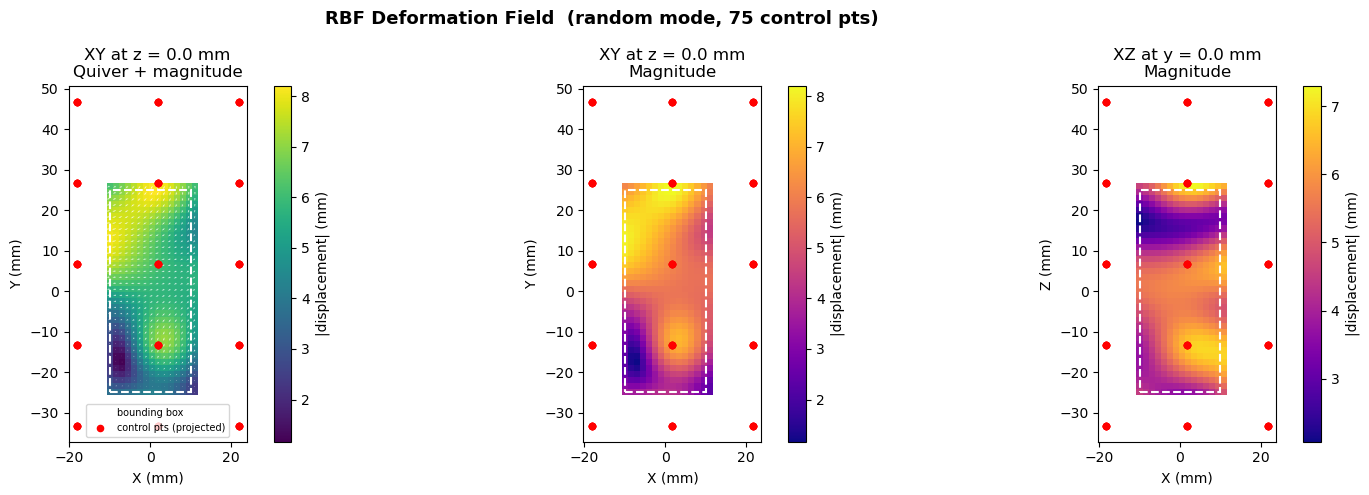

Magnitude — min 1.17 mm  max 8.21 mm  mean 5.61 mm


In [5]:
# ── Sample points inside the bounding box (not the grown field extent) ────
SAMPLE_STEP = max((_BBOX_MAX - _BBOX_MIN).max() / 40, BAKE_SPACING)
xs = np.arange(_BBOX_MIN[0], _BBOX_MAX[0] + SAMPLE_STEP, SAMPLE_STEP)
ys = np.arange(_BBOX_MIN[1], _BBOX_MAX[1] + SAMPLE_STEP, SAMPLE_STEP)
zs = np.arange(_BBOX_MIN[2], _BBOX_MAX[2] + SAMPLE_STEP, SAMPLE_STEP)

z_mid = float((_BBOX_MIN[2] + _BBOX_MAX[2]) / 2)
y_mid = float((_BBOX_MIN[1] + _BBOX_MAX[1]) / 2)

def _slice_xy(z_val):
    XX, YY = np.meshgrid(xs, ys, indexing='ij')
    ZZ = np.full_like(XX, z_val)
    pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])
    return field.get_displacement_batch(pts).reshape(len(xs), len(ys), 3)

def _slice_xz(y_val):
    XX, ZZ = np.meshgrid(xs, zs, indexing='ij')
    YY = np.full_like(XX, y_val)
    pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])
    return field.get_displacement_batch(pts).reshape(len(xs), len(zs), 3)

disp_xy = _slice_xy(z_mid)
disp_xz = _slice_xz(y_mid)
mag_xy  = np.linalg.norm(disp_xy, axis=-1)
mag_xz  = np.linalg.norm(disp_xz, axis=-1)

# ── Quiver subsample ──────────────────────────────────────────────────────
Q = max(1, len(xs) // 12)
XX_q, YY_q = np.meshgrid(xs[::Q], ys[::Q], indexing='ij')
DX_q = disp_xy[::Q, ::Q, 0]
DY_q = disp_xy[::Q, ::Q, 1]

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes_plt = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'RBF Deformation Field  ({RBF_MODE} mode, {len(ctrl_pts)} control pts)',
    fontsize=13, fontweight='bold')

def _box_rect(ax_x_range, ax_y_range, **kw):
    return plt.Rectangle(
        (ax_x_range[0], ax_y_range[0]),
        ax_x_range[1] - ax_x_range[0],
        ax_y_range[1] - ax_y_range[0],
        linewidth=1.5, edgecolor='white', facecolor='none', linestyle='--', **kw)

# Panel 1: quiver + magnitude (XY)
ax = axes_plt[0]
im = ax.pcolormesh(xs, ys, mag_xy.T, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, label='|displacement| (mm)')
scale = field.amplitude * Q * SAMPLE_STEP * 0.6 if field.amplitude > 0 else 1.0
ax.quiver(XX_q, YY_q, DX_q, DY_q,
          color='white', alpha=0.75, scale=scale, scale_units='xy', width=0.003)
ax.add_patch(_box_rect((_BBOX_MIN[0], _BBOX_MAX[0]), (_BBOX_MIN[1], _BBOX_MAX[1]),
                        label='bounding box'))
ax.scatter(ctrl_pts[:, 0], ctrl_pts[:, 1],
           c='red', s=20, zorder=5, label='control pts (projected)')
ax.set_aspect('equal');  ax.set_xlabel('X (mm)');  ax.set_ylabel('Y (mm)')
ax.set_title(f'XY at z = {z_mid:.1f} mm\nQuiver + magnitude');  ax.legend(fontsize=7)

# Panel 2: magnitude heatmap (XY)
ax2 = axes_plt[1]
im2 = ax2.pcolormesh(xs, ys, mag_xy.T, cmap='plasma', shading='auto')
fig.colorbar(im2, ax=ax2, label='|displacement| (mm)')
ax2.add_patch(_box_rect((_BBOX_MIN[0], _BBOX_MAX[0]), (_BBOX_MIN[1], _BBOX_MAX[1])))
ax2.scatter(ctrl_pts[:, 0], ctrl_pts[:, 1], c='red', s=20, zorder=5)
ax2.set_aspect('equal');  ax2.set_xlabel('X (mm)');  ax2.set_ylabel('Y (mm)')
ax2.set_title(f'XY at z = {z_mid:.1f} mm\nMagnitude')

# Panel 3: magnitude heatmap (XZ)
ax3 = axes_plt[2]
im3 = ax3.pcolormesh(xs, zs, mag_xz.T, cmap='plasma', shading='auto')
fig.colorbar(im3, ax=ax3, label='|displacement| (mm)')
ax3.add_patch(_box_rect((_BBOX_MIN[0], _BBOX_MAX[0]), (_BBOX_MIN[2], _BBOX_MAX[2])))
ax3.scatter(ctrl_pts[:, 0], ctrl_pts[:, 2], c='red', s=20, zorder=5)
ax3.set_aspect('equal');  ax3.set_xlabel('X (mm)');  ax3.set_ylabel('Z (mm)')
ax3.set_title(f'XZ at y = {y_mid:.1f} mm\nMagnitude')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'RBFDeformationField_slices.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Magnitude — min {mag_xy.min():.2f} mm  max {mag_xy.max():.2f} mm  mean {mag_xy.mean():.2f} mm')

## Cell 6 — Build geometry

Reads bounding object from Cell 2 and the field from Cell 4.

| Step | C# (`RandomTask`) | Python |
|------|-------------------|--------|
| 1 | `BaseBox(…).oConstructVoxels()` | `_build_bounding_voxels()` (box or STL) |
| 2 | `RandomDeformationField(…)` | `RBFDeformationField` (Cell 4) |
| 2b | `ImplicitRandomizedSchwarzPrimitive(…)` | `schwarz_rbf_sdf` closure |
| 3 | `voxBounding.voxIntersectImplicit(pattern)` | `Sh.voxIntersectImplicit` + `DelegateImplicit` |

`DelegateImplicit` (in `src/DelegateImplicit.cs`) wraps the Python SDF closure
as a `PicoGK.IImplicit` so C# can call it back for every active voxel.

In [6]:
def build_random_schwarz(
    output_dir: Path,
    rbf_field:  RBFDeformationField,
    f_unit_size: float      = F_UNIT_SIZE,
    f_wall_thickness: float = F_WALL_THICKNESS,
    headless: bool          = True,
):
    """Must be called inside a Library.Go task thread (via run_in_library)."""

    def preview(vox, colour=Cp.strRock, alpha=1.0):
        if not headless:
            Sh.PreviewVoxels(vox, colour, Single(alpha))

    # Step 1 — bounding voxels (box or STL, from Cell 2)
    print('  constructing bounding voxels …')
    vox_bounding = _build_bounding_voxels()

    # Step 2 — Python SDF closure: Schwarz Primitive + RBF displacement
    # Mirrors ImplicitRandomizedSchwarzPrimitive.fSignedDistance:
    #   vecNoise = field.vecGetData(vecPt)
    #   vecNewPt = vecPt + vecNoise
    #   dist = |cos(k*x) + cos(k*y) + cos(k*z)| - 0.5 * wallThickness
    k = (2.0 * math.pi) / f_unit_size

    def schwarz_rbf_sdf(vec) -> Single:
        x  = float(vec.X)
        y  = float(vec.Y)
        z  = float(vec.Z)
        dx, dy, dz = rbf_field.get_displacement(x, y, z)
        dist = (math.cos(k * (x + dx)) +
                math.cos(k * (y + dy)) +
                math.cos(k * (z + dz)))
        return Single(float(abs(dist) - 0.5 * f_wall_thickness))

    print('  creating DelegateImplicit …')
    impl = DelegateImplicit(Func[Vector3, Single](schwarz_rbf_sdf))

    # Step 3 — intersect
    print('  intersecting (each voxel calls back into Python) …')
    vox_implicit = Sh.voxIntersectImplicit(vox_bounding, impl)

    # Step 4 — preview (skipped in headless mode)
    preview(vox_implicit, Cp.strRandom())

    # Export
    vdb_path = str(output_dir / 'ImplicitRandomSchwarzPrimitive_Python.vdb')
    print(f'  exporting → {vdb_path}')
    export_voxels_to_vdb(vox_implicit, vdb_path)
    print('Finished Task successfully.')
    return vox_implicit


print('build_random_schwarz() defined.')

build_random_schwarz() defined.


## Cell 7 — Run the construction

| `HEADLESS` | Behaviour |
|---|---|
| `True` | No window. Fast, notebook-friendly. |
| `False` | PicoGK viewer opens; blocks until the window is closed. |

> **Performance** — every voxel evaluation calls back from C# into Python.
> At 0.5 mm on a 50 mm cube (~1M voxels) expect **30–90 s** depending on hardware.

In [7]:
import time

HEADLESS = False # set to True to skip viewer preview and speed up voxelisation

t0 = time.time()
print(f'Starting  (voxel size = {VOXEL_SIZE} mm, mode = {"headless" if HEADLESS else "with viewer"}) …')

def _task():
    build_random_schwarz(OUTPUT_DIR, field,
                         f_unit_size=F_UNIT_SIZE,
                         f_wall_thickness=F_WALL_THICKNESS,
                         headless=HEADLESS)

run_in_library(_task, voxel_size=VOXEL_SIZE, output_dir=OUTPUT_DIR, headless=HEADLESS)

print(f'Done in {time.time() - t0:.1f} s')
print(f'vdb written to: {vdb_PATH}')

Starting  (voxel size = 0.5 mm, mode = with viewer) …
      0s    0.0+ Opened /workspace/LEAP71_version_KBE/Examples/PicoGK.log
      0s    0.0+ 
      0s    0.0+ ----------------------------------------
      0s    0.0+ 
      0s    0.0+ Current time (UTC): 2026-05-01 09:10:24 (UTC)
      0s    0.0+ Current local time: 2026-05-01 09:10:24 (+00:00)
      0s    0.0+ 
      0s    0.0+ ----------------------------------------
      0s    0.0+ 
      0s    0.0+ System Info:
      0s    0.0+ 
      0s    0.0+ Machine Name:         ac438e247bf6
      0s    0.0+ Operating System      Ubuntu 24.04.4 LTS
      0s    0.0+ Version:              Unix 6.6.87.2
      0s    0.0+ OS Architecture:      X64
      0s    0.0+ Proc Architecture:    X64
      0s    0.0+ 64 Bit OS:            Yes
      0s    0.0+ 64 Bit Process:       Yes
      0s    0.0+ Processor Count:      20
      0s    0.0+ Working Set:          255MB
      0s    0.0+ C# Framework:         .NET 9.0.15
      0s    0.0+ C# CLR Version:  

Failed to create /mesa_shader_cache for shader cache (Permission denied)---disabling.


      0s    0.5+ PicoGK:    PicoGK Core Library
      0s    0.0+            1.7.1
      0s    0.0+            2026-04-29 09:19:06 picogk
      0s    0.0+ 
      0s    0.0+ VoxelSize: 0.5 (mm)
      0s    0.0+ Happy Computational Engineering!
      0s    0.0+ 
      0s    0.0+ 
      0s    0.0+ Loading lights embedded environment
      1s    0.0+ Starting tasks.
      1s    0.0+ 
  constructing bounding voxels …
      1s    0.0+ Loading Lights
  creating DelegateImplicit …
  intersecting (each voxel calls back into Python) …
  exporting → /workspace/LEAP71_version_KBE/Examples/ImplicitRandomSchwarzPrimitive_Python.vdb
Finished Task successfully.
     53s   52.1+ Viewer Window Closed
     53s    0.0+ 
     53s    0.0+ ----------------------------------------
     53s    0.0+ 
     53s    0.0+ Closing log file.
     53s    0.0+ Current time (UTC): 2026-05-01 09:11:16 (UTC)
     53s    0.0+ Current local time: 2026-05-01 09:11:16 (+00:00)
     53s    0.0+ Done.
Done in 52.7 s
vdb written t

## Cell 8 — Visualise the VDB with PyVista

Reading /workspace/LEAP71_version_KBE/Examples/ImplicitRandomSchwarzPrimitive_Python.vdb …
  shape : (105, 105, 45)   voxel size : 1.0 mm
  X [-22, 23]  Y [-52, 53]  Z [-2, 103] mm
Extracting isosurface …
  313,058 vertices, 635,492 triangles
  decimated → 245,315 vertices, 499,998 triangles


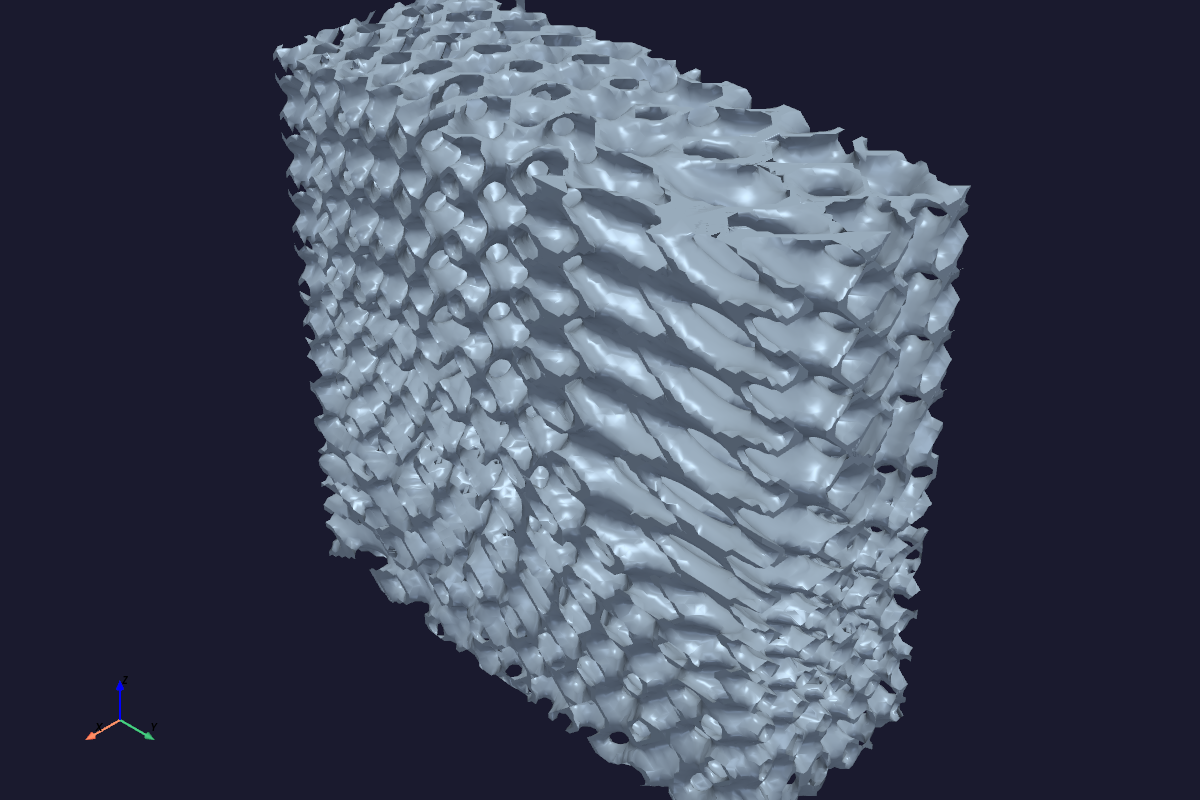

In [8]:
try:
    import pyvista as pv
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pyvista not found — install with:  pip install 'pyvista[jupyter]'"
    ) from exc

import os, sys
os.environ['MESA_SHADER_CACHE_DISABLE'] = '1'

VDB_READER_DIR = REPO_ROOT / 'vdb_reader'
if str(VDB_READER_DIR) not in sys.path:
    sys.path.insert(0, str(VDB_READER_DIR))
try:
    import vdb_numpy
except ImportError as exc:
    raise ImportError(
        f"vdb_numpy not found in {VDB_READER_DIR}. "
        f"Build with: cd {VDB_READER_DIR} && python setup.py build_ext --inplace"
    ) from exc

PYVISTA_BACKEND = 'static'
pv.set_jupyter_backend(PYVISTA_BACKEND)
pv.global_theme.allow_empty_mesh = True

if not vdb_PATH.exists():
    raise FileNotFoundError(f'VDB not found: {vdb_PATH}\nRun Cell 7 first.')

print(f'Reading {vdb_PATH} …')
arr, origin, voxel_size = vdb_numpy.read_vdb_as_numpy(str(vdb_PATH))
nz, ny, nx = arr.shape
ox, oy, oz = origin
print(f'  shape : {arr.shape}   voxel size : {voxel_size} mm')
print(f'  X [{ox:.0f}, {ox+nx*voxel_size:.0f}]  '
      f'Y [{oy:.0f}, {oy+ny*voxel_size:.0f}]  '
      f'Z [{oz:.0f}, {oz+nz*voxel_size:.0f}] mm')

grid = pv.ImageData(
    dimensions=(nx, ny, nz),
    spacing=(voxel_size,) * 3,
    origin=(ox, oy, oz),
)
grid.point_data['sdf'] = arr.flatten()

print('Extracting isosurface …')
surface = grid.contour([0.0], scalars='sdf')
print(f'  {surface.n_points:,} vertices, {surface.n_cells:,} triangles')

ratio = min(1.0, 500_000 / max(surface.n_cells, 1))
if ratio < 1.0:
    surface = surface.decimate(1.0 - ratio)
    print(f'  decimated → {surface.n_points:,} vertices, {surface.n_cells:,} triangles')

pl = pv.Plotter(notebook=True, off_screen=True, window_size=(1200, 800))
pl.set_background('#1a1a2e')
pl.add_mesh(surface, color='#8ca0b8', smooth_shading=True,
            specular=0.6, specular_power=30, ambient=0.2)
pl.add_axes(label_size=(0.04, 0.04))
pl.camera_position = 'iso'
pl.camera.zoom(1.2)
pl.show()

OPTIMIZATION STEPS: TBD